# Level-Pegging ⚖️
### Does equal-weighting the S&P *always* beat cap-weighting?

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Always wins?: Busted](https://img.shields.io/badge/Always_wins%3F-Busted-8b949e?style=flat-square)

You'll hear it everywhere: the equal-weight S&P (RSP) beats the regular cap-weight S&P (SPY) because it leans toward smaller companies and quietly *sells high, buys low* every rebalance. *Just buy RSP.* We hold both, dividends and fees included, and ask the one thing the word **always** can't survive: did equal-weight win **every** kind of market, or only some?

> 📓 **This is the plain-language layer.** The statistics, the alpha-vs-beta split and the regime test are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (level_pegging/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from level_pegging import data, strategy

AS_OF = "2026-06-12"
EW_FEE, CW_FEE, SPLIT = 20.0, 9.0, "2015-01-01"
frame = data.load_real("RSP", "SPY", mode="total_return").loc[:AS_OF]
net = strategy.race(frame, EW_FEE, CW_FEE)
ew, cw = net["ew"], net["cw"]
print(f"RSP (EW) + SPY (CW) total return: {len(frame):,} rows  {frame.index[0].date()} -> {frame.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(f"EW  Sharpe {ew['sharpe']:.3f}  maxDD {ew['max_dd']*100:.1f}%  CAGR {ew['cagr']*100:.2f}%")
print(f"CW  Sharpe {cw['sharpe']:.3f}  maxDD {cw['max_dd']*100:.1f}%  CAGR {cw['cagr']*100:.2f}%")


RSP (EW) + SPY (CW) total return: 5,817 rows  2003-05-01 -> 2026-06-12  fingerprint=8a1c86dd2b09
EW  Sharpe 0.630  maxDD -60.1%  CAGR 11.07%
CW  Sharpe 0.675  maxDD -55.2%  CAGR 11.39%


## The answer first 🎯

| Question | Answer |
|---|---|
| Does equal-weight *always* beat cap-weight? | **No.** It *led* from 2003-2015 (**+2.6%/yr**) and *lagged* from 2015-2026 (**-2.7%/yr**). |
| Over RSP's whole life, who won? | **Cap-weight (SPY)** — equal-weight earned **-0.32 pts/yr less** (11.07% vs 11.39%/yr, net of fees). |
| So what *is* equal-weighting? | A **bet on small caps and broad markets** — it pays when leadership widens and loses when a few giants run. |

## 1 · The claim

*"Equal-weighting **always** beats cap-weighting. RSP tilts to smaller names and harvests a rebalancing premium — sell what went up, buy what went down. Just buy RSP and forget the cap-weight index."* It's the standard pitch for equal-weight funds, and the academic version (Plyakha, Uppal & Vilkov) found a real edge in long US history.

## 2 · So what?

If a different *weighting* of the **same 500 stocks** reliably beat the index everyone owns, the default choice — cap-weighted indexing — would be a mistake worth trillions. That's a big enough claim to deserve a fair, literal test on the real investable fund rather than a back-fitted index.

## 3 · How would we even know?

We hold **RSP** (equal-weight) and **SPY** (cap-weight), both total return (dividends in), net each of its fee (RSP **20 bps/yr**, SPY **9 bps/yr**), and compare. The catch the word *always* hides: a single full-sample average can hide a sign **flip**. So we also cut the history at the start of the mega-cap era (**2015**) and ask whether the two halves really tell different stories. If equal-weight wins one half and loses the other, *"always"* is dead.

## 4 · The teardown — let's actually look

First, the two equity curves.

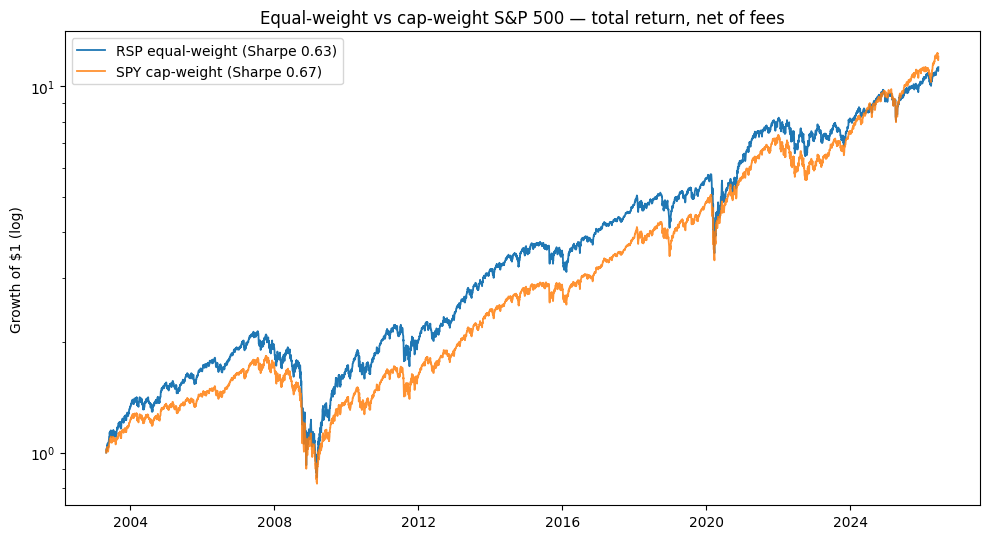

In [2]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(ew['equity'], label=f"RSP equal-weight (Sharpe {ew['sharpe']:.2f})", lw=1.3)
ax.plot(cw['equity'], label=f"SPY cap-weight (Sharpe {cw['sharpe']:.2f})", lw=1.3, alpha=.85)
ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log)')
ax.set_title('Equal-weight vs cap-weight S&P 500 — total return, net of fees'); ax.legend()
plt.tight_layout(); plt.show()

The lines are almost on top of each other — *level-pegging* — for years. The real story isn't the levels, it's **who's ahead, when**. So plot the ratio: RSP's wealth divided by SPY's. Up = equal-weight winning; down = cap-weight winning.

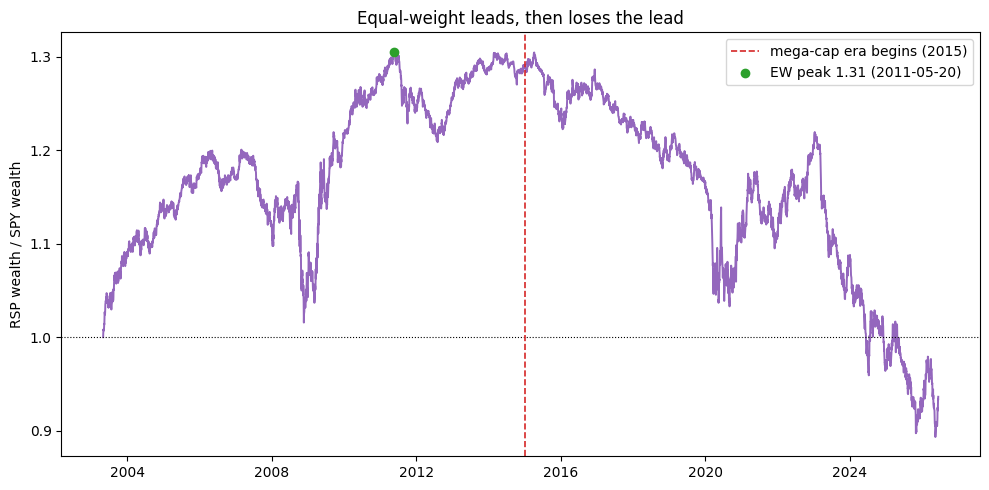

relative wealth: peak 1.305 on 2011-05-20  ->  end 0.936


In [3]:
rel = ew['equity'] / cw['equity']
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rel, color='C4', lw=1.4)
ax.axhline(1.0, color='k', lw=.8, ls=':')
ax.axvline(pd.Timestamp(SPLIT), color='C3', lw=1.2, ls='--', label='mega-cap era begins (2015)')
peak = rel.idxmax()
ax.scatter([peak], [rel.max()], color='C2', zorder=5, label=f'EW peak {rel.max():.2f} ({peak.date()})')
ax.set_ylabel('RSP wealth / SPY wealth'); ax.set_title('Equal-weight leads, then loses the lead')
ax.legend(); plt.tight_layout(); plt.show()
print(f'relative wealth: peak {rel.max():.3f} on {peak.date()}  ->  end {rel.iloc[-1]:.3f}')

There it is. Equal-weight climbed to **1.305×** SPY by **2011-05-20** — it really *was* winning through the broad 2000s recovery. Then the mega-caps took over and the line fell all the way back to **0.936**: today RSP has earned **less** than SPY over its whole life. The premium didn't vanish into noise — it *reversed*.

Split the history at 2015 and the two halves disagree out loud:

In [4]:
early = frame.loc[:SPLIT]; late = frame.loc[SPLIT:]
re_, rl = strategy.race(early, EW_FEE, CW_FEE), strategy.race(late, EW_FEE, CW_FEE)
tbl = pd.DataFrame({
  'EW CAGR %': [re_['ew']['cagr']*100, rl['ew']['cagr']*100],
  'CW CAGR %': [re_['cw']['cagr']*100, rl['cw']['cagr']*100],
  'EW-CW pts': [re_['ew_minus_cw_cagr']*100, rl['ew_minus_cw_cagr']*100],
  'winner':    ['EW' if re_['ew_minus_cw_cagr']>0 else 'CW', 'EW' if rl['ew_minus_cw_cagr']>0 else 'CW'],
}, index=['2003-2015 (broadening)', '2015-2026 (mega-cap)'])
tbl.round(2)

,EW CAGR %,CW CAGR %,EW-CW pts,winner
2003-2015 (broadening),11.630,9.210,2.420,EW
2015-2026 (mega-cap),10.500,13.660,-3.160,CW


Equal-weight **wins the first half and loses the second**. That's not a free lunch — it's a *bet on which companies lead*.

## 5 · The verdict

- **Always wins? → Busted.** EW led to a 1.305× lead by 2011, then gave it all back to end at 0.936× — it has *underperformed* SPY over its full investable life.
- **Signal → Mixed.** Real-ish edge early (+2.6%/yr), negative late (-2.7%/yr); the full-sample number is the wrong sign and statistically zero.
- **Just buy RSP? → Mirage.** Net of its higher fee it earns **-0.32 pts/yr less**. The tilt only pays if you correctly time the breadth regime.

## 6 · Could you actually trade it?

You can trade both — RSP and SPY are liquid funds. The catch isn't capacity, it's that *"just buy RSP"* is a **bet on market breadth in disguise**. It pays when small caps and the average stock lead, and it loses — as it did for a decade — when a handful of giants carry the index. Net of RSP's higher fee and quarterly rebalancing turnover, the full-sample scoreboard favours plain cap-weight.

## 7 · Going further 🚪

- Does an equal-weight tilt pay better **outside the US**, where indices are less mega-cap concentrated?
- Is there a **breadth signal** (advance/decline, top-10 weight) that times *when* to hold equal-weight?
- How much of the early-2000s EW win was just the **small-cap value** rally? Fork it and strip the factors.